# Telco Customer Churn Analysis

## Business Problem

Telecommunication companies lose revenue when customers leave their services.

The goal of this project is to identify the factors associated with customer churn and provide actionable recommendations to improve customer retention.

# Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# Data Audit

## Dataset Shape

In [2]:
df.shape

(7043, 21)

## Data Types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Missing Values

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Insight

The dataset contains no missing values in most columns. However, TotalCharges contains blank strings that must be converted before numerical analysis can be performed.

## Duplicate Records

In [5]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [6]:
df['TotalCharges'].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [7]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [9]:
df['TotalCharges'].dtype

dtype('float64')

## Cleaning Summary

- Replaced blank values in TotalCharges with NaN
- Converted TotalCharges from object to float
- Verified data consistency before analysis

# Exploratory Data Analysis

## Churn Distribution

In [10]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

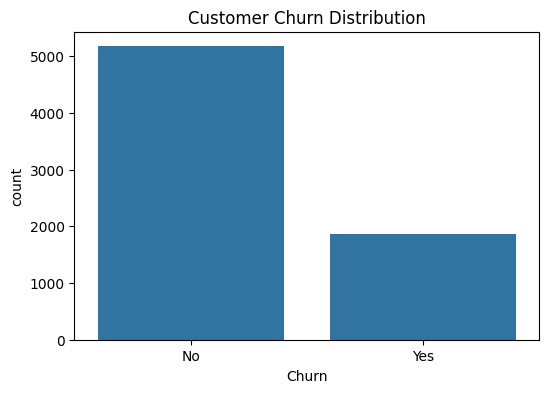

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Customer Churn Distribution')
plt.show()

### Insight

Approximately 26.5% of customers have churned.

This indicates that more than one quarter of the customer base has left the company, suggesting a significant retention challenge.

Further analysis is required to identify the factors associated with churn.

## Question:
Does contract type affect churn?

In [13]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


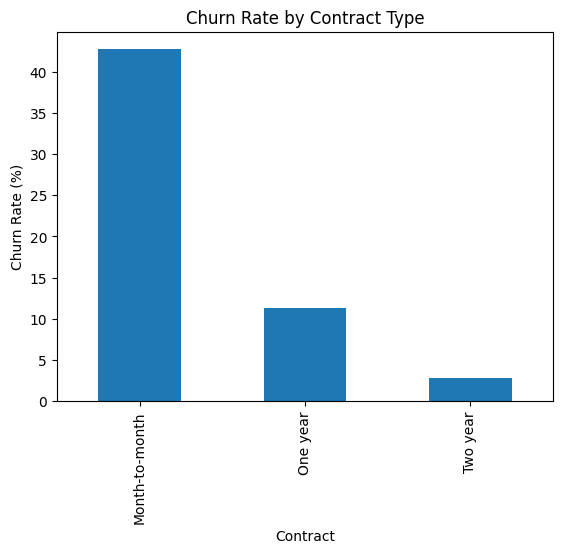

In [14]:
contract_churn = (
    pd.crosstab(
        df['Contract'],
        df['Churn'],
        normalize='index'
    ) * 100
)

contract_churn['Yes'].plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type')
plt.show()

## Insight
Contract type appears to be one of the strongest predictors of customer churn. Customers on month-to-month contracts exhibit a churn rate of 42.7%, compared with only 11.3% for one-year contracts and 2.8% for two-year contracts. This suggests that longer contractual commitments are strongly associated with customer retention. Encouraging customers to transition from month-to-month plans to longer-term contracts may significantly reduce churn.

## Question 
How does customer tenure relate to churn?

In [15]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


## Insight

Customers who churn have significantly shorter tenure than retained customers.

The average tenure of churned customers is approximately 18 months, compared with 38 months for retained customers.

Additionally, 50% of churned customers leave within their first 10 months, suggesting that the early stages of the customer lifecycle are particularly vulnerable to churn.

These findings indicate that customer retention efforts should focus on improving the onboarding experience and engagement during the first year of service.

## Tenure Distribution by Churn Status

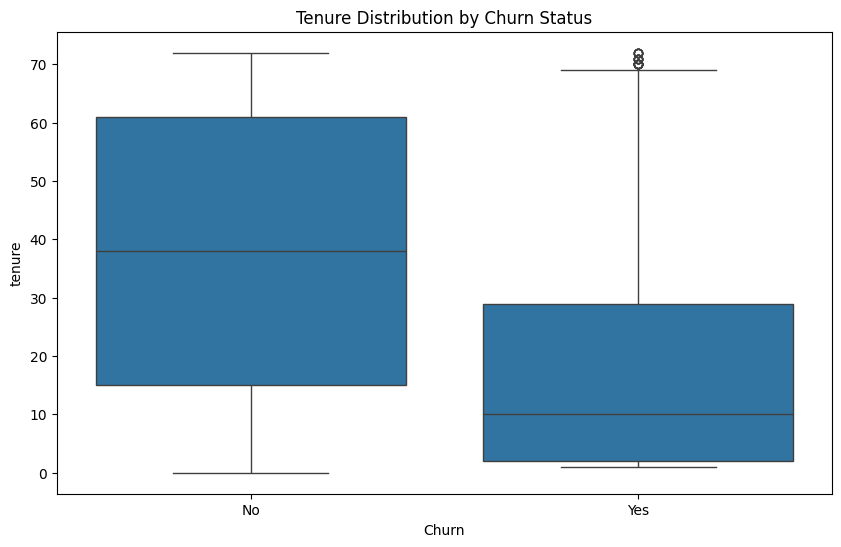

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Tenure Distribution by Churn Status')
plt.show()

## Insight

The boxplot reveals a substantial difference in tenure between churned and retained customers.

Customers who churn tend to have significantly shorter tenure, with a median tenure of approximately 10 months, compared to around 38 months for retained customers.

This suggests that the risk of churn is highest during the early stages of the customer lifecycle. However, the presence of long-tenure churned customers indicates that customer churn is not limited to new customers alone.

These findings highlight the importance of improving customer onboarding and engagement during the first year of service.

## Question
Does monthly charge affect customer churn?


In [17]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


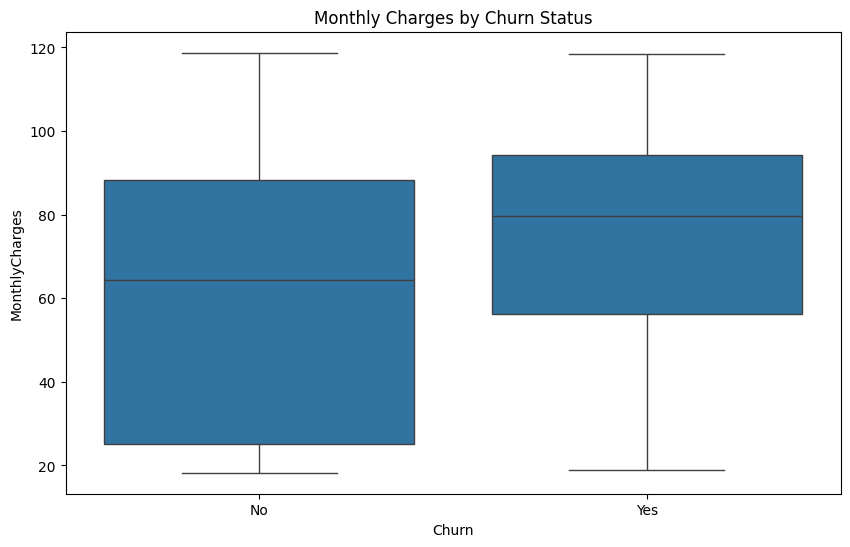

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn Status')
plt.show()

## Insight

Customers who churn have significantly higher monthly charges than retained customers.

The average monthly charge for churned customers is approximately 74.4, compared with 61.3 for retained customers. This pattern is also reflected in the median values, suggesting that the difference is consistent across the customer base rather than being driven by a few extreme observations.

This finding indicates that customers paying higher monthly fees may be more sensitive to pricing, service quality, or perceived value. Because these customers contribute more revenue, their churn represents a disproportionately high financial risk to the business

## Question
Does internet service type influence churn?

In [19]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
)*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


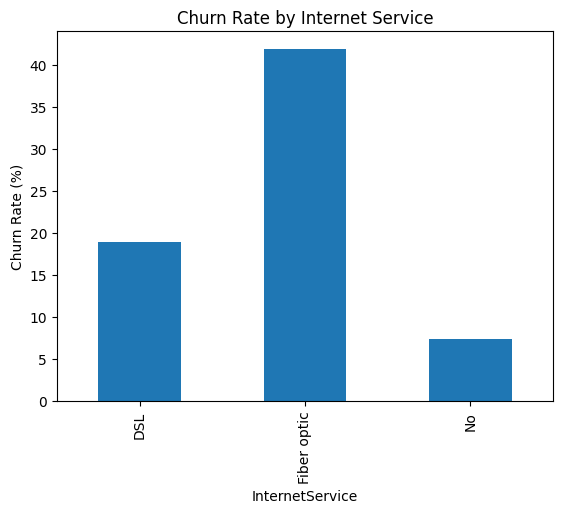

In [20]:
internet_churn = (
    pd.crosstab(
        df['InternetService'],
        df['Churn'],
        normalize='index'
    ) * 100
)

internet_churn['Yes'].plot(
    kind='bar'
)

plt.title(
    'Churn Rate by Internet Service'
)

plt.ylabel('Churn Rate (%)')
plt.show()

## Insight

Internet service type appears to be strongly associated with customer churn.

Customers using Fiber Optic services have the highest churn rate (41.9%), compared with DSL customers (19.0%) and customers without internet service (7.4%).

This suggests that Fiber Optic customers represent a high-risk segment. However, additional investigation is needed to determine whether the higher churn rate is related to pricing, customer expectations, service quality, or other underlying factors.

In [21]:
pd.crosstab(
    [df['InternetService'], df['Contract']],
    df['Churn'],
    normalize='index'
) * 100

Churn                                  No        Yes
InternetService Contract                            
DSL             Month-to-month  67.784137  32.215863
                One year        90.701754   9.298246
                Two year        98.089172   1.910828
Fiber optic     Month-to-month  45.394737  54.605263
                One year        80.705009  19.294991
                Two year        92.773893   7.226107
No              Month-to-month  81.106870  18.893130
                One year        97.527473   2.472527
                Two year        99.216301   0.783699

## Insight

A combined analysis of internet service type and contract type reveals a high-risk customer segment.

Customers using Fiber Optic internet on month-to-month contracts exhibit the highest churn rate in the dataset (54.6%). In contrast, customers without internet service on two-year contracts show the lowest churn rate (0.8%).

This suggests that churn risk is influenced by the interaction of multiple factors rather than a single variable. Customers with premium internet services and short-term contractual commitments appear to be particularly vulnerable to churn and should be prioritized in retention initiatives.

## Question 
Does technical support reduce churn?

In [22]:
pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


## Insight

Customers without technical support exhibit a churn rate of 41.6%, compared with only 15.2% among customers who have technical support services.

This strong difference suggests that access to technical support is associated with higher customer retention. Customers without support services may experience unresolved issues or lower engagement, increasing their likelihood of churn.

Providing additional support options or encouraging adoption of technical support

# Feature Engineering

## Service Count

In [23]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df[service_cols].head()

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,No,No phone service,No,Yes,No,No,No,No
1,Yes,No,Yes,No,Yes,No,No,No
2,Yes,No,Yes,Yes,No,No,No,No
3,No,No phone service,Yes,No,Yes,Yes,No,No
4,Yes,No,No,No,No,No,No,No


## Service Count Feature

Question

Does the number of subscribed services affect customer churn?

In [24]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['ServiceCount'] = (
    df[service_cols]
    .isin(['Yes'])
    .sum(axis=1)
)

In [25]:
df['ServiceCount'].describe()

count    7043.000000
mean        2.037910
std         1.847682
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: ServiceCount, dtype: float64

In [26]:
df['ServiceCount'].value_counts().sort_index()

ServiceCount
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

In [27]:
pd.crosstab(
    df['ServiceCount'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
ServiceCount,,
0,78.593961,21.406039
1,54.244306,45.755694
2,64.181994,35.818006
3,72.629696,27.370304
4,77.699531,22.300469
5,87.565674,12.434326
6,94.718310,5.281690


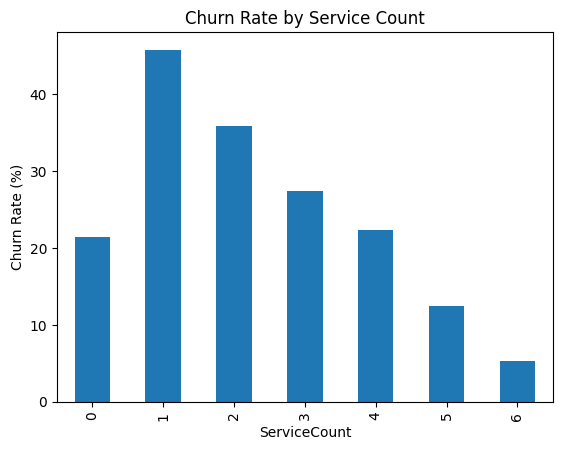

In [28]:
service_churn = (
    pd.crosstab(
        df['ServiceCount'],
        df['Churn'],
        normalize='index'
    ) * 100
)

service_churn['Yes'].plot(
    kind='bar'
)

plt.title(
    'Churn Rate by Service Count'
)

plt.ylabel('Churn Rate (%)')
plt.show()

## Insight

A custom Service Count feature was created to measure customer engagement across optional services.

The analysis reveals a strong inverse relationship between service adoption and churn. Customers with only one subscribed service show the highest churn rate (45.8%), while customers subscribed to all six services exhibit a churn rate of only 5.3%.

This suggests that customers who are more deeply integrated into the company's ecosystem are significantly less likely to leave. Increasing cross-sell and upsell opportunities may therefore improve customer retention and reduce churn risk.

# High Risk Customer Profile

## Question

Can a combination of risk factors identify high-risk customers?

In [29]:
df['HighRiskProfile'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['TechSupport'] == 'No')
)

In [30]:
df['HighRiskProfile'].value_counts()

HighRiskProfile
False    5247
True     1796
Name: count, dtype: int64

In [31]:
pd.crosstab(
    df['HighRiskProfile'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
HighRiskProfile,,
False,84.067086,15.932914
True,42.483296,57.516704


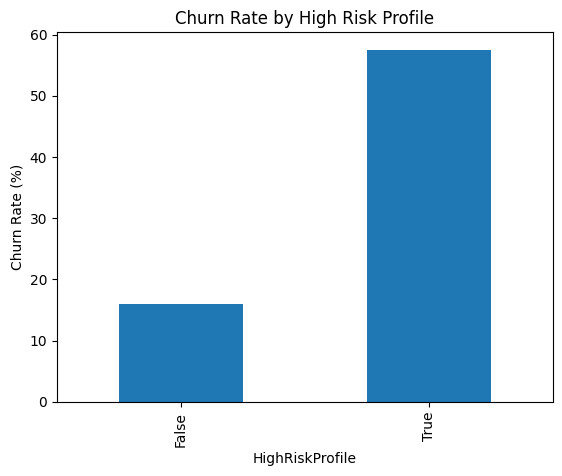

In [32]:
risk_churn = (
    pd.crosstab(
        df['HighRiskProfile'],
        df['Churn'],
        normalize='index'
    ) * 100
)

risk_churn['Yes'].plot(
    kind='bar'
)

plt.title(
    'Churn Rate by High Risk Profile'
)

plt.ylabel('Churn Rate (%)')
plt.show()

## Insight

A custom High-Risk Customer Profile was created by combining three churn-related factors: Month-to-Month Contract, Fiber Optic Internet Service, and No Technical Support.

Customers matching this profile exhibited a churn rate of 57.5%, compared with only 15.9% among all other customers.

This indicates that churn risk increases substantially when multiple risk factors occur together. Rather than evaluating each factor independently, analyzing their combined effect provides a more effective way to identify vulnerable customer segments.

From a business perspective, customers in this segment should be prioritized for retention initiatives such as contract conversion offers, technical support adoption campaigns, and targeted engagement programs.
While this profile does not identify all churned customers, it successfully isolates a customer segment with a significantly elevated churn risk, making it useful for targeted retention strategies.


# Feature Importance Analysis 
## Question
Which variables best separate churned and retained customers?

This section evaluates which variables show the strongest differences between churned and retained customers. For numerical variables, we compare group means and medians. For categorical variables, we compare churn rates across categories.

## Numerical Variables

In [33]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount'] 
numeric_summary = ( df.groupby('Churn')[numeric_cols] .agg(['mean', 'median']) .T ) 
numeric_summary

Churn                           No          Yes
tenure         mean      37.569965    17.979133
               median    38.000000    10.000000
MonthlyCharges mean      61.265124    74.441332
               median    64.425000    79.650000
TotalCharges   mean    2555.344141  1531.796094
               median  1683.600000   703.550000
ServiceCount   mean       2.135292     1.768325
               median     2.000000     2.000000

## Insight

Among the numerical variables, tenure shows the strongest separation between churned and retained customers. Customers who churn have substantially shorter tenure, indicating that churn risk is highest during the early stages of the customer lifecycle.

MonthlyCharges is another important differentiator, as churned customers tend to pay higher monthly fees on average. TotalCharges and ServiceCount also contribute meaningful separation, but their effects are less pronounced than tenure.

## Categorical Variables

In [34]:
categorical_cols = [ 'Contract', 'InternetService', 'TechSupport', 'PaymentMethod', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies' ]
for col in categorical_cols: 
    print(f"\n===== {col} =====") 
    display( pd.crosstab( df[col], df['Churn'], normalize='index' ) * 100 )


===== Contract =====


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



===== InternetService =====


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980



===== TechSupport =====


...

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064



===== StreamingTV =====


Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188



===== StreamingMovies =====


Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


## Insight

The strongest categorical differentiators are Contract, TechSupport, and InternetService.

Customers on month-to-month contracts show dramatically higher churn rates than customers with one-year or two-year contracts. Similarly, customers without technical support are far more likely to churn than those with support services. Fiber Optic customers also exhibit elevated churn rates, especially when combined with short-term contracts and lack of support.

## Overall Conclusion

The variables with the strongest power to distinguish churned from retained customers are:

• Tenure (numerical)
• Contract type (categorical)
• MonthlyCharges (numerical)
• TechSupport (categorical)
• InternetService (categorical)

These variables should be prioritized in retention analysis and any future churn prediction modeling.

# Business Recommendations

1. Focus on Month-to-Month Customers

Month-to-month customers show the highest churn rates and should be prioritized for contract conversion campaigns.

2. Promote Technical Support Adoption

Customers without technical support are significantly more likely to churn.

3. Target High-Risk Profiles

Customers with Fiber Optic service, Month-to-Month contracts, and no technical support represent the most vulnerable customer segment.

4. Increase Service Adoption

Customers using multiple services exhibit substantially lower churn rates.

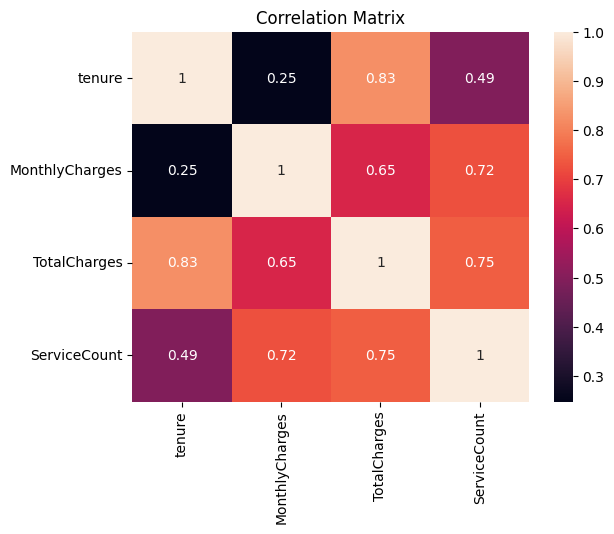

In [35]:
corr_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'ServiceCount'
]

sns.heatmap(
    df[corr_cols].corr(),
    annot=True
)

plt.title(
    'Correlation Matrix'
)

plt.show()